# Quantitative experiment plots

This notebook reads the newest run directory from `Results/Quantitative_experiment_comparison`. Timing plots use the per-event rows in `summary.csv`; Jaccard similarity uses only checkpoint rows from `checkpoint_summary.csv`.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pandas.errors import EmptyDataError

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "Notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_ROOT = PROJECT_ROOT / "Results" / "Quantitative_experiment_comparison"
run_dirs = sorted(path for path in RESULTS_ROOT.iterdir() if path.is_dir() and path.name.startswith("run_"))
if not run_dirs:
    raise FileNotFoundError(f"No run_* directories found in {RESULTS_ROOT}")

RUN_DIR = run_dirs[-1]
SUMMARY_PATH = RUN_DIR / "summary.csv"
CHECKPOINT_SUMMARY_PATH = RUN_DIR / "checkpoint_summary.csv"
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"summary.csv not found in newest run directory: {RUN_DIR}")
if not CHECKPOINT_SUMMARY_PATH.exists():
    raise FileNotFoundError(f"checkpoint_summary.csv not found in newest run directory: {RUN_DIR}")

RUN_DIR


PosixPath('/Users/piotr/Praca/Nauka/publikacje/SNNs_ST_Patterns/Experiments_software/Results/Quantitative_experiment_comparison/run_20260602_113111')

In [2]:
summary = pd.read_csv(SUMMARY_PATH)
checkpoint_summary = pd.read_csv(CHECKPOINT_SUMMARY_PATH)

required_summary_columns = {
    "event_type_count",
    "online_theta",
    "algorithm",
    "event_count",
    "mining_seconds",
}
missing_columns = required_summary_columns.difference(summary.columns)
if missing_columns:
    raise ValueError(f"summary.csv is missing required columns: {sorted(missing_columns)}")

required_checkpoint_columns = required_summary_columns | {"rules_path"}
missing_checkpoint_columns = required_checkpoint_columns.difference(checkpoint_summary.columns)
if missing_checkpoint_columns:
    raise ValueError(f"checkpoint_summary.csv is missing required columns: {sorted(missing_checkpoint_columns)}")

summary = summary.sort_values(
    ["event_type_count", "online_theta", "algorithm", "event_count"],
    ignore_index=True,
)
checkpoint_summary = checkpoint_summary.sort_values(
    ["event_type_count", "online_theta", "algorithm", "event_count"],
    ignore_index=True,
)

summary["cumulative_selected_mining_seconds"] = (
    summary
    .groupby(["event_type_count", "online_theta", "algorithm"])["mining_seconds"]
    .cumsum()
)

summary.head()


,event_type_count,online_theta,algorithm,event_count,is_checkpoint,rule_count,raw_rule_count,target_rule_count,significant_synapse_count,mining_seconds,...,spatial_radius,temporal_window,threshold,attempt_count,tuning_seconds,within_tolerance,window_start_time,window_end_time,window_event_count,cumulative_selected_mining_seconds
0,15,0.1,online_stdr,1,False,0,0.0,0,0.0,0.002836,...,NaN,NaN,0.1,NaN,0.002836,True,NaN,NaN,NaN,0.002836
1,15,0.1,online_stdr,2,False,0,0.0,0,0.0,0.003670,...,NaN,NaN,0.1,NaN,0.003670,True,NaN,NaN,NaN,0.006506
2,15,0.1,online_stdr,3,False,0,0.0,0,0.0,0.002998,...,NaN,NaN,0.1,NaN,0.002998,True,NaN,NaN,NaN,0.009504
3,15,0.1,online_stdr,4,False,0,0.0,0,0.0,0.002806,...,NaN,NaN,0.1,NaN,0.002806,True,NaN,NaN,NaN,0.012309
4,15,0.1,online_stdr,5,False,0,0.0,0,0.0,0.002087,...,NaN,NaN,0.1,NaN,0.002087,True,NaN,NaN,NaN,0.014397


## Per-event cumulative mining time

These plots use every event-prefix timing row generated by the experiment notebook.


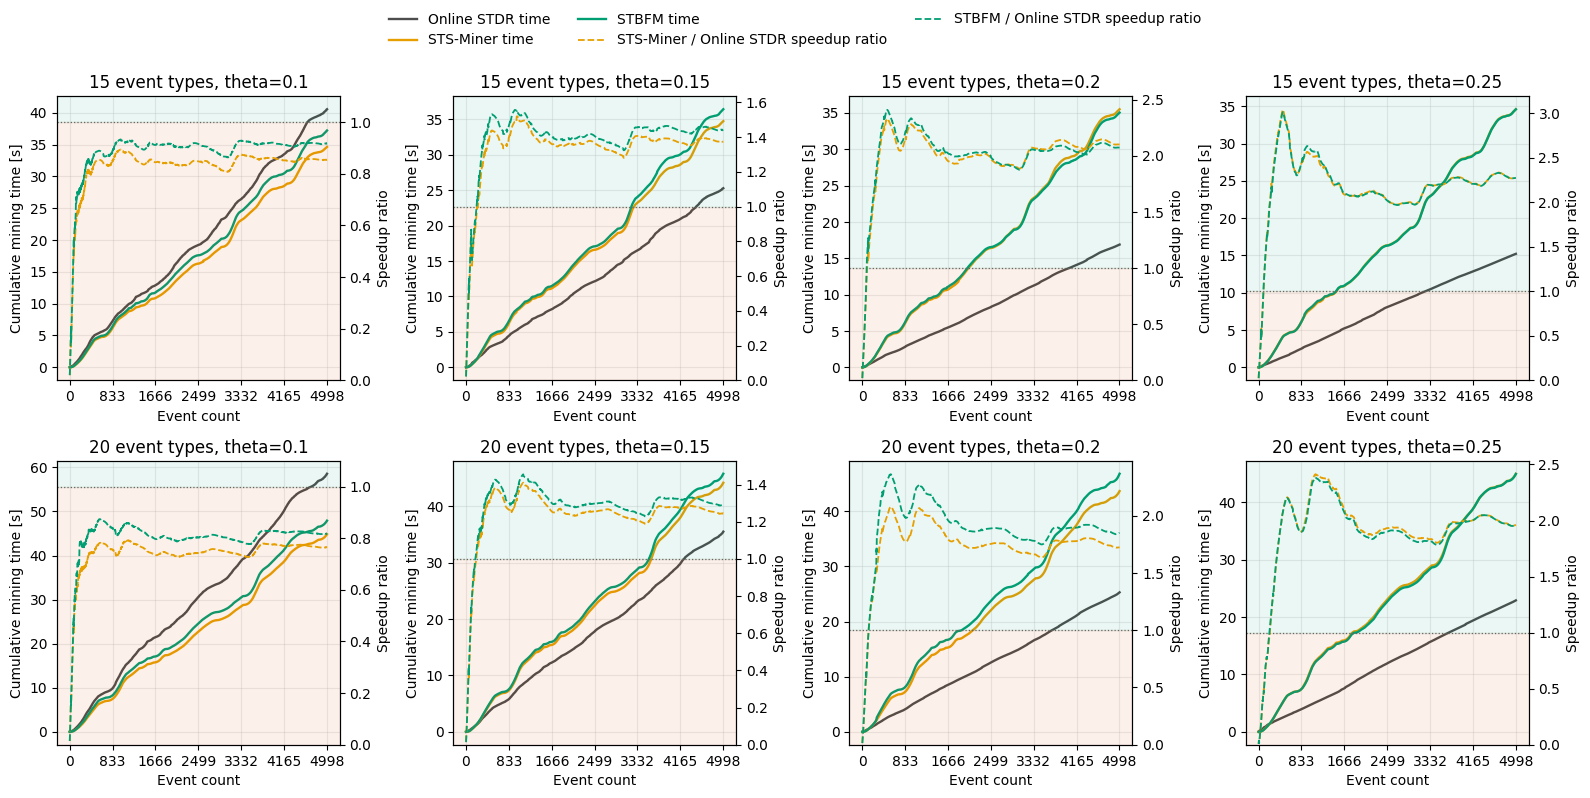

PosixPath('/Users/piotr/Praca/Nauka/publikacje/SNNs_ST_Patterns/Experiments_software/Results/Quantitative_experiment_comparison/run_20260602_113111/plots_cumulative/cumulative_mining_time_grid.png')

In [8]:
plot_dir = RUN_DIR / "plots_cumulative"
plot_dir.mkdir(parents=True, exist_ok=True)

algorithm_labels = {
    "online_stdr": "Online STDR",
    "sts_miner": "STS-Miner",
    "stbfm": "STBFM",
}
algorithm_colors = {
    "online_stdr": "#4D4D4D",
    "sts_miner": "#E69F00",
    "stbfm": "#009E73",
}
algorithm_order = ["online_stdr", "sts_miner", "stbfm"]
baseline_order = ["sts_miner", "stbfm"]
event_type_counts = sorted(summary["event_type_count"].dropna().unique())
online_thetas = sorted(summary["online_theta"].dropna().unique())
MAX_X_TICKS = 6

fig, axes = plt.subplots(
    nrows=len(event_type_counts),
    ncols=len(online_thetas),
    figsize=(16, max(5, 4 * len(event_type_counts))),
    sharex=False,
    sharey=False,
)
if len(event_type_counts) == 1 and len(online_thetas) == 1:
    axes = [[axes]]
elif len(event_type_counts) == 1:
    axes = [axes]
elif len(online_thetas) == 1:
    axes = [[ax] for ax in axes]

legend_handles = []
legend_labels = []
for row_index, event_type_count in enumerate(event_type_counts):
    for col_index, online_theta in enumerate(online_thetas):
        ax = axes[row_index][col_index]
        ax_speedup = ax.twinx()
        speedup_values = []
        subset = summary[
            (summary["event_type_count"] == event_type_count)
            & (summary["online_theta"].round(10) == round(float(online_theta), 10))
        ].copy()
        if subset.empty:
            ax.set_visible(False)
            ax_speedup.set_visible(False)
            continue

        rows_by_algorithm = {
            algorithm: subset[subset["algorithm"] == algorithm].sort_values("event_count")
            for algorithm in algorithm_order
        }

        for algorithm in algorithm_order:
            algorithm_rows = rows_by_algorithm[algorithm]
            if algorithm_rows.empty:
                continue
            line, = ax.plot(
                algorithm_rows["event_count"],
                algorithm_rows["cumulative_selected_mining_seconds"],
                linewidth=1.7,
                color=algorithm_colors.get(algorithm),
                label=f"{algorithm_labels.get(algorithm, algorithm)} time",
            )
            if row_index == 0 and col_index == 0:
                legend_handles.append(line)
                legend_labels.append(line.get_label())

        online_rows = rows_by_algorithm["online_stdr"]
        if not online_rows.empty:
            online_times = online_rows[["event_count", "cumulative_selected_mining_seconds"]].rename(
                columns={"cumulative_selected_mining_seconds": "online_cumulative_seconds"}
            )
            for baseline_algorithm in baseline_order:
                baseline_rows = rows_by_algorithm[baseline_algorithm]
                if baseline_rows.empty:
                    continue
                speedup_rows = baseline_rows[["event_count", "cumulative_selected_mining_seconds"]].merge(
                    online_times,
                    on="event_count",
                    how="inner",
                )
                speedup_rows = speedup_rows[speedup_rows["online_cumulative_seconds"] > 0]
                if speedup_rows.empty:
                    continue
                speedup = speedup_rows["cumulative_selected_mining_seconds"] / speedup_rows["online_cumulative_seconds"]
                speedup_values.extend(float(value) for value in speedup.dropna())
                line, = ax_speedup.plot(
                    speedup_rows["event_count"],
                    speedup,
                    linestyle="--",
                    linewidth=1.3,
                    color=algorithm_colors.get(baseline_algorithm),
                    label=f"{algorithm_labels[baseline_algorithm]} / Online STDR speedup ratio",
                )
                if row_index == 0 and col_index == 0:
                    legend_handles.append(line)
                    legend_labels.append(line.get_label())

        if speedup_values:
            speedup_upper = max(1.1, max(speedup_values) * 1.05)
            ax_speedup.set_ylim(0.0, speedup_upper)
            ax_speedup.axhspan(0.0, 1.0, color="#E34902", alpha=0.08, zorder=0)
            ax_speedup.axhspan(1.0, speedup_upper, color="#009E73", alpha=0.08, zorder=0)
            ax_speedup.axhline(1.0, color="#666666", linewidth=0.9, linestyle=":", zorder=1)

        ax.set_title(f"{int(event_type_count)} event types, theta={online_theta:g}")
        ax.set_xlabel("Event count")
        ax.set_ylabel("Cumulative mining time [s]")
        ax.grid(True, alpha=0.25)
        ax_speedup.set_ylabel("Speedup ratio")

        max_event_count = int(subset["event_count"].max())
        tick_step = max(1, max_event_count // MAX_X_TICKS)
        ax.set_xticks(list(range(0, max_event_count + 1, tick_step)))

fig.legend(legend_handles, legend_labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.93))
output_path = plot_dir / "cumulative_mining_time_grid.png"
fig.savefig(output_path, dpi=150)
plt.show()

output_path


## Checkpoint rule-set Jaccard similarity

Jaccard similarity is computed only from checkpoint rule snapshots saved by the experiment notebook.


In [4]:
def resolve_result_path(path_value: str | Path) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def rule_sequence_set(rules_path: str | Path) -> set[str]:
    if pd.isna(rules_path):
        return set()
    path = resolve_result_path(rules_path)
    if not path.exists() or path.stat().st_size == 0:
        return set()

    try:
        rules = pd.read_csv(path)
    except EmptyDataError:
        return set()
    if rules.empty:
        return set()
    if "event_type_rule" in rules.columns:
        sequence_column = "event_type_rule"
    elif "sequence" in rules.columns:
        sequence_column = "sequence"
    else:
        raise ValueError(f"No rule sequence column found in {path}")

    return {
        " -> ".join(part.strip() for part in str(sequence).split("->"))
        for sequence in rules[sequence_column].dropna()
    }


def jaccard_similarity(left: set[str], right: set[str]) -> float:
    union = left | right
    if not union:
        return 1.0
    return len(left & right) / len(union)


def precision_recall_f1(reference: set[str], candidate: set[str]) -> tuple[float, float, float]:
    true_positive_count = len(reference & candidate)
    precision = 1.0 if not candidate else true_positive_count / len(candidate)
    recall = 1.0 if not reference else true_positive_count / len(reference)
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2.0 * precision * recall / (precision + recall)
    return precision, recall, f1


In [5]:
comparison_algorithms = ["sts_miner", "stbfm", "sts_miner_vs_stbfm"]
similarity_rows = []

for (event_type_count, online_theta, event_count), rows in checkpoint_summary.groupby(
    ["event_type_count", "online_theta", "event_count"]
):
    rows_by_algorithm = rows.set_index("algorithm")
    rule_sets = {}
    for algorithm in ("online_stdr", "sts_miner", "stbfm"):
        if algorithm in rows_by_algorithm.index:
            rule_sets[algorithm] = rule_sequence_set(rows_by_algorithm.loc[algorithm, "rules_path"])

    comparison_pairs = [
        ("sts_miner", "online_stdr", "sts_miner"),
        ("stbfm", "online_stdr", "stbfm"),
        ("sts_miner_vs_stbfm", "sts_miner", "stbfm"),
    ]
    for comparison_name, left_algorithm, right_algorithm in comparison_pairs:
        if left_algorithm not in rule_sets or right_algorithm not in rule_sets:
            continue
        left_rules = rule_sets[left_algorithm]
        right_rules = rule_sets[right_algorithm]
        precision, recall, f1 = precision_recall_f1(reference=left_rules, candidate=right_rules)
        similarity_rows.append({
            "event_type_count": int(event_type_count),
            "online_theta": float(online_theta),
            "event_count": int(event_count),
            "baseline_algorithm": comparison_name,
            "reference_algorithm": left_algorithm,
            "candidate_algorithm": right_algorithm,
            "reference_rule_sequences": len(left_rules),
            "candidate_rule_sequences": len(right_rules),
            "intersection_size": len(left_rules & right_rules),
            "union_size": len(left_rules | right_rules),
            "jaccard_similarity": jaccard_similarity(left_rules, right_rules),
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
        })

similarity_columns = [
    "event_type_count",
    "online_theta",
    "event_count",
    "baseline_algorithm",
    "reference_algorithm",
    "candidate_algorithm",
    "reference_rule_sequences",
    "candidate_rule_sequences",
    "intersection_size",
    "union_size",
    "jaccard_similarity",
    "precision",
    "recall",
    "f1_score",
]
similarity_by_checkpoint = pd.DataFrame(similarity_rows, columns=similarity_columns)
if not similarity_by_checkpoint.empty:
    similarity_by_checkpoint = similarity_by_checkpoint.sort_values(
        ["event_type_count", "online_theta", "baseline_algorithm", "event_count"],
        ignore_index=True,
    )
    similarity_summary = similarity_by_checkpoint.groupby(
        ["event_type_count", "online_theta", "baseline_algorithm"],
        as_index=False,
    ).agg(
        average_jaccard_similarity=("jaccard_similarity", "mean"),
        std_jaccard_similarity=("jaccard_similarity", "std"),
        average_precision=("precision", "mean"),
        std_precision=("precision", "std"),
        average_recall=("recall", "mean"),
        std_recall=("recall", "std"),
        average_f1_score=("f1_score", "mean"),
        std_f1_score=("f1_score", "std"),
        checkpoints=("event_count", "count"),
    )
else:
    similarity_summary = pd.DataFrame(
        columns=[
            "event_type_count",
            "online_theta",
            "baseline_algorithm",
            "average_jaccard_similarity",
            "std_jaccard_similarity",
            "average_precision",
            "std_precision",
            "average_recall",
            "std_recall",
            "average_f1_score",
            "std_f1_score",
            "checkpoints",
        ]
    )

similarity_dir = RUN_DIR / "plots_similarity"
similarity_dir.mkdir(parents=True, exist_ok=True)
similarity_by_checkpoint.to_csv(similarity_dir / "similarity_by_checkpoint.csv", index=False)
similarity_summary = similarity_summary.fillna(0.0)
similarity_summary.to_csv(similarity_dir / "similarity_summary.csv", index=False)

# Backward-compatible names for the plotting cell below.
jaccard_by_checkpoint = similarity_by_checkpoint
jaccard_summary = similarity_summary
jaccard_by_checkpoint.to_csv(similarity_dir / "jaccard_by_checkpoint.csv", index=False)
jaccard_summary[[
    "event_type_count",
    "online_theta",
    "baseline_algorithm",
    "average_jaccard_similarity",
    "std_jaccard_similarity",
    "checkpoints",
]].to_csv(similarity_dir / "jaccard_summary.csv", index=False)
similarity_summary


,event_type_count,online_theta,baseline_algorithm,average_jaccard_similarity,std_jaccard_similarity,checkpoints
0,15,0.10,stbfm,0.628574,0.213351,25
1,15,0.10,sts_miner,0.531806,0.177944,25
2,15,0.10,sts_miner_vs_stbfm,0.657971,0.150830,25
3,15,0.15,stbfm,0.402285,0.233797,25
4,15,0.15,sts_miner,0.412658,0.223613,25
5,15,0.15,sts_miner_vs_stbfm,0.564155,0.192419,25
6,15,0.20,stbfm,0.207128,0.260314,25
7,15,0.20,sts_miner,0.225562,0.248092,25
8,15,0.20,sts_miner_vs_stbfm,0.366527,0.256431,25
9,15,0.25,stbfm,0.108960,0.274994,25


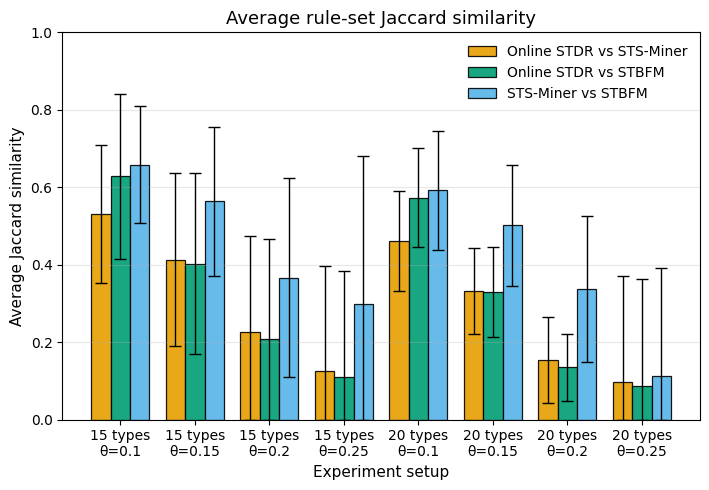

PosixPath('/Users/piotr/Praca/Nauka/publikacje/SNNs_ST_Patterns/Experiments_software/Results/Quantitative_experiment_comparison/run_20260602_113111/plots_similarity/average_jaccard_grouped.png')

In [12]:
baseline_titles = {
    "sts_miner": "Online STDR vs STS-Miner",
    "stbfm": "Online STDR vs STBFM",
    "sts_miner_vs_stbfm": "STS-Miner vs STBFM",
}
baseline_colors = {
    "sts_miner": "#E69F00",
    "stbfm": "#009E73",
    "sts_miner_vs_stbfm": "#56B4E9",
}
comparison_algorithms = ["sts_miner", "stbfm", "sts_miner_vs_stbfm"]

setup_keys = sorted(
    jaccard_summary[["event_type_count", "online_theta"]].drop_duplicates().itertuples(index=False, name=None)
)
setup_labels = [f"{int(event_type_count)} types\nθ={online_theta:g}" for event_type_count, online_theta in setup_keys]
x_positions = list(range(len(setup_keys)))
bar_width = 0.26
offsets = {
    "sts_miner": -bar_width,
    "stbfm": 0.0,
    "sts_miner_vs_stbfm": bar_width,
}

fig, ax = plt.subplots(figsize=(max(4, len(setup_keys) * 0.9), 5))
for comparison_algorithm in comparison_algorithms:
    means = []
    lower_errors = []
    upper_errors = []
    for event_type_count, online_theta in setup_keys:
        row = jaccard_summary[
            (jaccard_summary["event_type_count"] == event_type_count)
            & (jaccard_summary["online_theta"].round(10) == round(float(online_theta), 10))
            & (jaccard_summary["baseline_algorithm"] == comparison_algorithm)
        ]
        if row.empty:
            mean = 0.0
            std = 0.0
        else:
            mean = float(row["average_jaccard_similarity"].iloc[0])
            std = float(row["std_jaccard_similarity"].iloc[0])
        means.append(mean)
        lower_errors.append(min(std, mean))
        upper_errors.append(std)

    ax.bar(
        [position + offsets[comparison_algorithm] for position in x_positions],
        means,
        width=bar_width,
        yerr=[lower_errors, upper_errors],
        capsize=4,
        color=baseline_colors[comparison_algorithm],
        edgecolor="black",
        linewidth=0.9,
        alpha=0.9,
        label=baseline_titles[comparison_algorithm],
        error_kw={"elinewidth": 1.0, "capthick": 1.0, "ecolor": "black"},
    )

ax.set_title("Average rule-set Jaccard similarity", fontsize=13)
ax.set_xlabel("Experiment setup", fontsize=11)
ax.set_ylabel("Average Jaccard similarity", fontsize=11)
ax.set_xticks(x_positions)
ax.set_xticklabels(setup_labels)
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()

output_path = similarity_dir / "average_jaccard_grouped.png"
fig.savefig(output_path, dpi=150)
plt.show()

output_path


## Precision, recall, and F1 averages

This section visualizes the averaged checkpoint precision, recall, and F1 scores computed from the saved rule snapshots. For Online STDR comparisons, Online STDR is the reference set and the offline method is the candidate set.


In [7]:
metric_columns = [
    "average_precision",
    "average_recall",
    "average_f1_score",
]
required_columns = {"event_type_count", "online_theta", "baseline_algorithm", *metric_columns}
missing_columns = required_columns.difference(similarity_summary.columns)
if missing_columns:
    raise ValueError(f"similarity_summary is missing required columns: {sorted(missing_columns)}")

prf_summary = similarity_summary[
    ["event_type_count", "online_theta", "baseline_algorithm", "checkpoints", *metric_columns]
].copy()
prf_summary = prf_summary.sort_values(
    ["event_type_count", "online_theta", "baseline_algorithm"],
    ignore_index=True,
)
prf_summary.to_csv(similarity_dir / "precision_recall_f1_summary.csv", index=False)
prf_summary


,event_type_count,online_theta,baseline_algorithm,checkpoints,average_precision,average_recall,average_f1_score
0,15,0.10,stbfm,25,0.781410,0.754216,0.746505
1,15,0.10,sts_miner,25,0.818950,0.602624,0.674962
2,15,0.10,sts_miner_vs_stbfm,25,0.703784,0.905719,0.784036
3,15,0.15,stbfm,25,0.534813,0.546008,0.538406
4,15,0.15,sts_miner,25,0.574918,0.535243,0.553207
5,15,0.15,sts_miner_vs_stbfm,25,0.672662,0.745388,0.702062
6,15,0.20,stbfm,25,0.444519,0.296653,0.289354
7,15,0.20,sts_miner,25,0.327373,0.318146,0.322073
8,15,0.20,sts_miner_vs_stbfm,25,0.632842,0.513246,0.488249
9,15,0.25,stbfm,25,0.600153,0.149409,0.130378


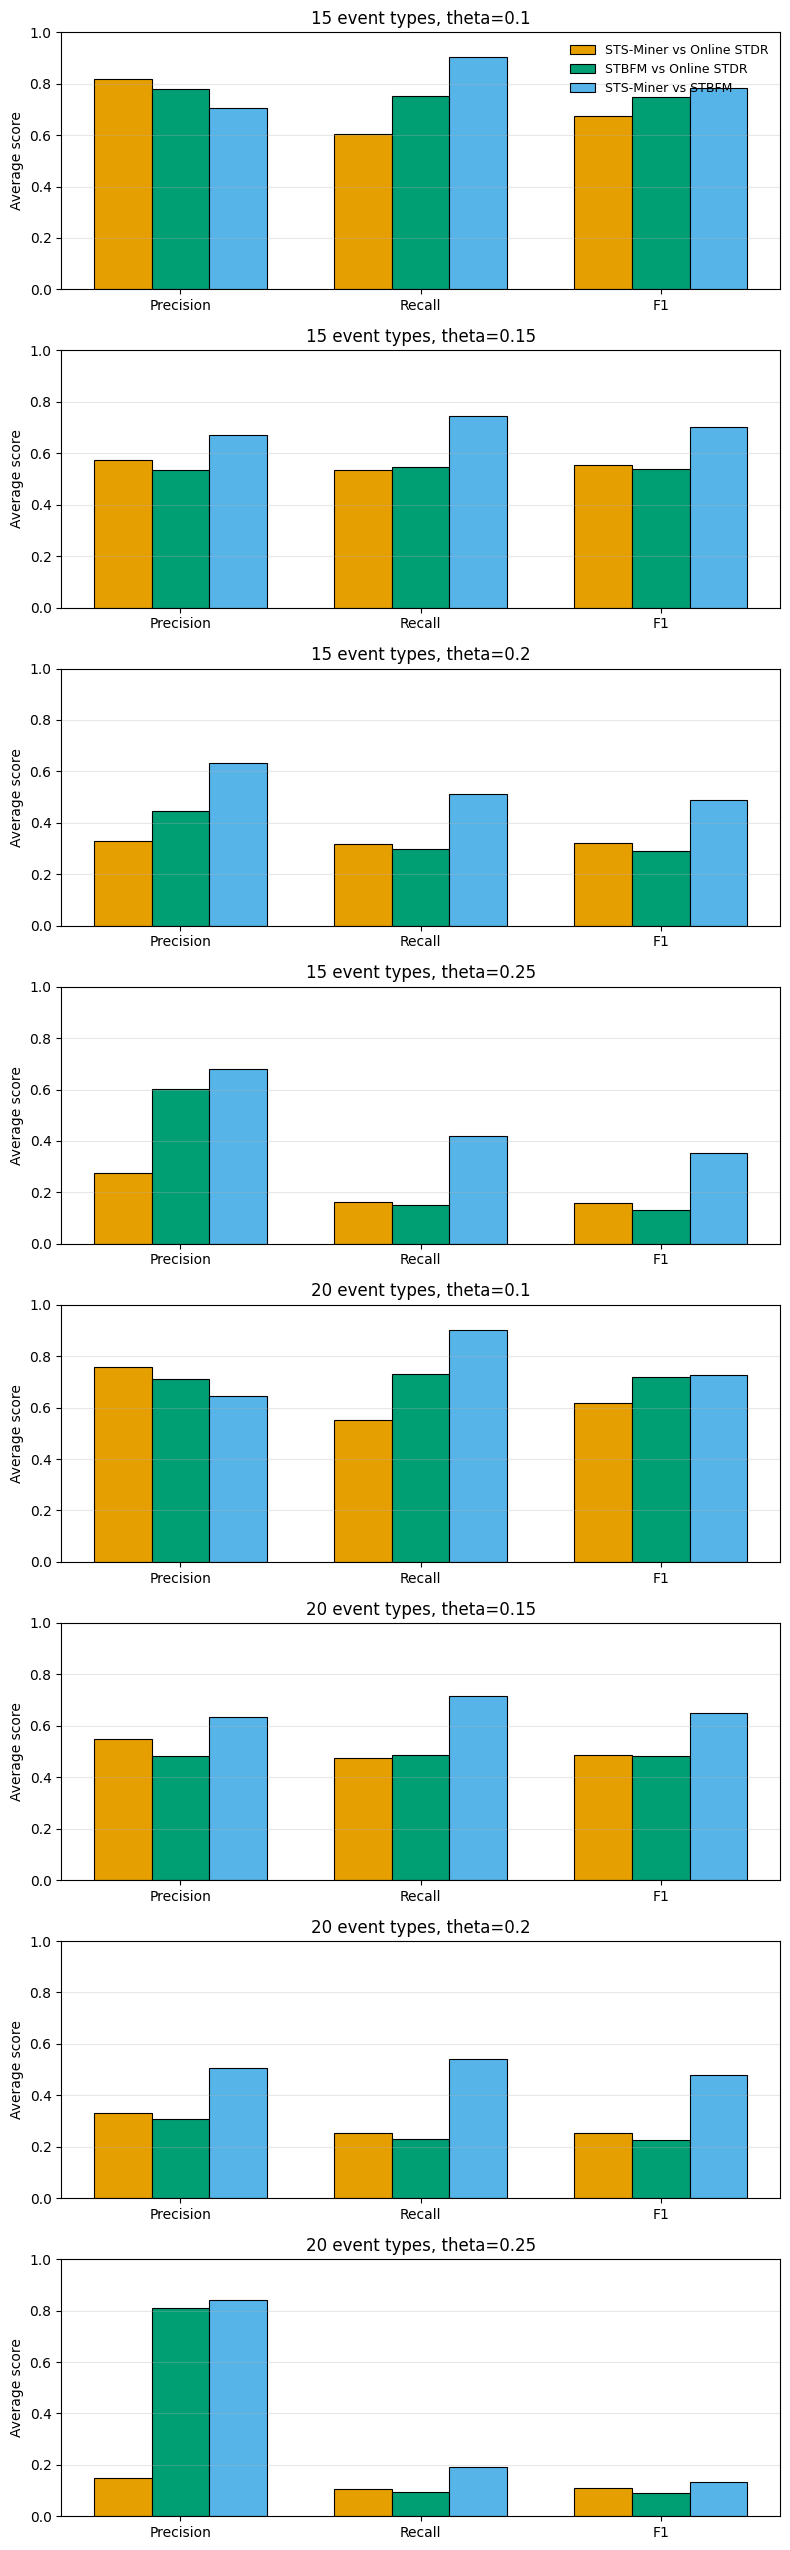

PosixPath('/Users/piotr/Praca/Nauka/publikacje/SNNs_ST_Patterns/Experiments_software/Results/Quantitative_experiment_comparison/run_20260602_113111/plots_similarity/average_precision_recall_f1_grouped.png')

In [8]:
metric_labels = {
    "average_precision": "Precision",
    "average_recall": "Recall",
    "average_f1_score": "F1",
}
comparison_labels = {
    "sts_miner": "STS-Miner vs Online STDR",
    "stbfm": "STBFM vs Online STDR",
    "sts_miner_vs_stbfm": "STS-Miner vs STBFM",
}
comparison_colors = {
    "sts_miner": "#E69F00",
    "stbfm": "#009E73",
    "sts_miner_vs_stbfm": "#56B4E9",
}

if prf_summary.empty:
    raise ValueError("No precision/recall/F1 rows are available. Run the similarity cell first.")

setup_keys = sorted(
    prf_summary[["event_type_count", "online_theta"]].drop_duplicates().itertuples(index=False, name=None)
)
fig, axes = plt.subplots(
    nrows=len(setup_keys),
    ncols=1,
    figsize=(8, max(4, 3.2 * len(setup_keys))),
    squeeze=False,
)

x_positions = list(range(len(metric_columns)))
bar_width = 0.24
comparison_order = [
    comparison for comparison in ("sts_miner", "stbfm", "sts_miner_vs_stbfm")
    if comparison in set(prf_summary["baseline_algorithm"])
]
offsets = {
    comparison: (index - (len(comparison_order) - 1) / 2) * bar_width
    for index, comparison in enumerate(comparison_order)
}

for row_index, (event_type_count, online_theta) in enumerate(setup_keys):
    ax = axes[row_index][0]
    subset = prf_summary[
        (prf_summary["event_type_count"] == event_type_count)
        & (prf_summary["online_theta"].round(10) == round(float(online_theta), 10))
    ]
    for comparison in comparison_order:
        comparison_row = subset[subset["baseline_algorithm"] == comparison]
        if comparison_row.empty:
            continue
        values = [float(comparison_row[metric].iloc[0]) for metric in metric_columns]
        ax.bar(
            [position + offsets[comparison] for position in x_positions],
            values,
            width=bar_width,
            color=comparison_colors.get(comparison),
            edgecolor="black",
            linewidth=0.8,
            label=comparison_labels.get(comparison, comparison),
        )
    ax.set_title(f"{int(event_type_count)} event types, theta={online_theta:g}")
    ax.set_xticks(x_positions)
    ax.set_xticklabels([metric_labels[metric] for metric in metric_columns])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Average score")
    ax.grid(True, axis="y", alpha=0.3)
    if row_index == 0:
        ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
output_path = similarity_dir / "average_precision_recall_f1_grouped.png"
fig.savefig(output_path, dpi=150)
plt.show()

output_path
